# v8: Real Text Training — Sequence-Level Diffusion Routing
## From Synthetic Patterns to Natural Language

**Author:** David Ledbetter  
**Created:** 03/13/2026  
**Lineage:** v7.3 architecture (deep supervision, additive forces, content-aware memory, gated residual)

### Version History

- **v8.0** (03/13/2026 22:00): Initial real text. fiber_dim=192, 3 blocks, 2M params.  
  Result: Val BPC 3.17, Val Acc 35%, Val PPL 9.0. Capacity-limited (train-val gap 0.02).
- **v8.1** (03/14/2026 00:15): Scale up dense components. fiber_dim=256, 4 blocks,  
  1024 atoms, 2-layer context MLP with 4x expansion. ~6-7M params.
- **v8.2** (03/14/2026 01:00): Scale up GEOMETRIC components. Per-subbundle memory  
  banks (8 independent dictionaries), manifold_dim 64->128, langevin_steps 5->8.  
  Reduced context_expand 4->2 (shift capacity from dense to geometric).

---

### What This Notebook Does

Trains the v7.3 Spectral-Gauge architecture on **real text** (Tiny Shakespeare)  
using character-level tokenization (vocab=256, zero dependencies).

### Architecture Summary (from v7.3)

- **Sequence-level Langevin settling**: cross-position causal mixing fused  
  with Hopfield energy descent at every settling step
- **Three additive forces**: Hopfield gradient (settle) + causal context force  
  (route) + lateral inhibition (compete)
- **Per-step context scheduling**: high context early (explore), low late (commit)
- **Ramping sparsity**: no thresholding early, full thresholding late
- **Content-aware memory bank**: routes on [position, content], not just position
- **Gated residual**: preserves sparsity from settling
- **Deep supervision**: shared decoder reads every block's output

### Key Scaling Decisions

- **Character-level** (not BPE): vocab=256, no tokenizer dependencies, direct  
  byte-level modeling. Every character is its own token.
- **seq_len=64**: short enough for CPU training, long enough to capture  
  word-level and short phrase-level patterns.
- **Step-based training**: the dataset is large (~1M chars), so we train  
  for a fixed number of steps rather than epochs.

In [86]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple
from dataclasses import dataclass
import math
import os
import urllib.request
from tqdm.notebook import tqdm

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


---
## 1. Download and Prepare Tiny Shakespeare

In [87]:
data_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data")
os.makedirs(data_dir, exist_ok=True)
data_path = os.path.join(data_dir, "input.txt")

if not os.path.exists(data_path):
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    print(f"Downloading Tiny Shakespeare...")
    urllib.request.urlretrieve(url, data_path)
    print("Done.")
else:
    print(f"Data already exists at {data_path}")

with open(data_path, "r") as f:
    text = f.read()

print(f"Total characters: {len(text):,}")
print(f"Unique characters: {len(set(text))}")
print(f"\nFirst 200 chars:")
print(text[:200])

Data already exists at /Users/davidledbetter/SparseGeometricSignalTransport/v8_real_text/data/input.txt
Total characters: 1,115,394
Unique characters: 65

First 200 chars:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [88]:
# Character-level tokenization: each byte is its own token (vocab=256)
# No tokenizer dependencies needed.

def encode(s: str) -> list:
    return [ord(c) for c in s]

def decode(tokens: list) -> str:
    return "".join(chr(t) for t in tokens if 0 <= t < 256)


# Encode full corpus
data = torch.tensor(encode(text), dtype=torch.long)
print(f"Encoded tensor: {data.shape}")

# Train/val split (90/10)
n = len(data)
split = int(0.9 * n)
train_data = data[:split]
val_data = data[split:]
print(f"Train: {len(train_data):,} chars")
print(f"Val:   {len(val_data):,} chars")

# Verify roundtrip
sample = data[:50].tolist()
print(f"\nRoundtrip check: '{decode(sample)}'")

Encoded tensor: torch.Size([1115394])
Train: 1,003,854 chars
Val:   111,540 chars

Roundtrip check: 'First Citizen:
Before we proceed any further, hear'


---
## 2. Configuration (Scaled for Real Text)

In [89]:
@dataclass
class ArchitectureConfig:
    """Configuration scaled for character-level real text."""

    # === CONFIG HISTORY ===
    # v8.0 (03/13/2026 22:00): Initial real text config. fiber_dim=192, n_blocks=3,
    #   n_dictionary_atoms=512, context_proj=Linear(D,D)->Tanh. 2M params.
    #   Result: Val BPC 3.17, Val Acc 35%, Val PPL 9.0. Train-val gap 0.02 (capacity-limited).
    # v8.1 (03/14/2026 00:15): Scale up dense components.
    #   fiber_dim 192->256, n_blocks 3->4, n_dictionary_atoms 512->1024, k_wta 64->96.
    #   context_proj upgraded to 2-layer MLP with 4x expansion. ~6-7M params.
    # v8.2 (03/14/2026 01:00): Scale up GEOMETRIC components (not dense layers).
    #   Per-subbundle memory banks: each subbundle gets its own dictionary.
    #   manifold_dim 64->128: deeper base manifold.
    #   langevin_steps 5->8: more settling = more reasoning in the geometric core.
    #   context_expand 4->2: REDUCE dense expansion, shift capacity to geometry.

    # --- Fiber Bundle Geometry ---
    fiber_dim: int = 256
    n_subbundles: int = 8
    manifold_dim: int = 128          # v8.2: 64 -> 128 (deeper base manifold)

    # --- Vocabulary & Embedding ---
    vocab_size: int = 256
    max_seq_len: int = 128

    # --- Sparse Dictionary (per-subbundle in v8.2) ---
    atoms_per_subbundle: int = 128   # v8.2: each subbundle gets its own dictionary
    k_wta_per_subbundle: int = 16    # v8.2: k-WTA within each subbundle

    # --- Architecture ---
    n_blocks: int = 4
    context_expand: int = 2          # v8.2: 4 -> 2 (shift capacity to geometry)

    # --- Sequence-Level Langevin ---
    langevin_steps: int = 8          # v8.2: 5 -> 8 (more settling = more reasoning)
    langevin_lr: float = 0.1
    beta_init: float = 1.0
    beta_final: float = 10.0

    # --- Sparsity ---
    sparsity_lambda: float = 0.3
    inhibition_gamma: float = 0.1

    # --- Training ---
    learning_rate: float = 3e-4
    dropout: float = 0.1
    batch_size: int = 16
    seq_len: int = 64
    max_steps: int = 5000
    eval_interval: int = 100
    eval_steps: int = 20

    @property
    def subbundle_dim(self) -> int:
        assert self.fiber_dim % self.n_subbundles == 0
        return self.fiber_dim // self.n_subbundles


config = ArchitectureConfig()
print(f"Fiber dim: {config.fiber_dim} = {config.n_subbundles} subbundles x {config.subbundle_dim} dims each")
print(f"Vocab: {config.vocab_size} (character-level)")
print(f"Seq len: {config.seq_len}, Blocks: {config.n_blocks}, Langevin steps: {config.langevin_steps}")
print(f"Training: {config.max_steps} steps, batch_size={config.batch_size}")
print(f"Tokens per step: {config.batch_size * config.seq_len:,}")
print(f"Total training tokens: ~{config.max_steps * config.batch_size * config.seq_len:,}")

Fiber dim: 256 = 8 subbundles x 32 dims each
Vocab: 256 (character-level)
Seq len: 64, Blocks: 4, Langevin steps: 8
Training: 5000 steps, batch_size=16
Tokens per step: 1,024
Total training tokens: ~5,120,000


---
## 3. Data Loader

In [90]:
def get_batch(split_data: torch.Tensor, cfg: ArchitectureConfig):
    """Sample a random batch of contiguous chunks from the corpus."""
    max_start = len(split_data) - cfg.seq_len - 1
    starts = torch.randint(0, max_start, (cfg.batch_size,))
    x = torch.stack([split_data[s : s + cfg.seq_len] for s in starts])
    return x.to(device)


# Test
batch = get_batch(train_data, config)
print(f"Batch shape: {batch.shape}")
print(f"Sample: '{decode(batch[0, :40].tolist())}'")

Batch shape: torch.Size([16, 64])
Sample: 'd, lips, O you
The doors of breath, seal'


In [91]:
# --- Show what training looks like ---
print("WHAT THE MODEL SEES AND PREDICTS")
print("=" * 70)
print(f"Each training example is {config.seq_len} consecutive characters.")
print(f"The model predicts the NEXT character at every position.")
print(f"This is autoregressive: position t sees chars 0..t, predicts char t+1.\n")

sample_batch = get_batch(train_data, config)
for i in range(3):
    text_in = decode(sample_batch[i].tolist())
    print(f"Example {i+1}:")
    print(f"  Full chunk: '{text_in}'")
    print(f"  Input  (positions 0..{config.seq_len-2}): '{text_in[:-1]}'")
    print(f"  Target (positions 1..{config.seq_len-1}): '{text_in[1:]}'")
    print()
    print(f"  Character-by-character predictions:")
    for pos in [0, 5, 15, 30, 50]:
        if pos + 1 < len(text_in):
            ctx = text_in[max(0, pos-10):pos+1]
            target_char = text_in[pos+1]
            target_repr = repr(target_char)
            print(f"    pos {pos:2d}: context='...{ctx}' -> predict {target_repr}")
    print()

print(f"Batch shape: {sample_batch.shape}")
print(f"Predictions per batch: {config.batch_size} seqs x {config.seq_len - 1} positions = "
      f"{config.batch_size * (config.seq_len - 1):,} next-char predictions")

WHAT THE MODEL SEES AND PREDICTS
Each training example is 64 consecutive characters.
The model predicts the NEXT character at every position.
This is autoregressive: position t sees chars 0..t, predicts char t+1.

Example 1:
  Full chunk: 'riend no less
Than those she placeth highest! So, farewell.

LAR'
  Input  (positions 0..62): 'riend no less
Than those she placeth highest! So, farewell.

LA'
  Target (positions 1..63): 'iend no less
Than those she placeth highest! So, farewell.

LAR'

  Character-by-character predictions:
    pos  0: context='...r' -> predict 'i'
    pos  5: context='...riend ' -> predict 'n'
    pos 15: context='... no less
Th' -> predict 'a'
    pos 30: context='...hose she pl' -> predict 'a'
    pos 50: context='...hest! So, f' -> predict 'a'

Example 2:
  Full chunk: ':
It cannot be avoided but by this;
It will not be avoided but b'
  Input  (positions 0..62): ':
It cannot be avoided but by this;
It will not be avoided but '
  Target (positions 1..63): '
It ca

---
## 4. Architecture (v7.3 — Full Port)

All components from v7.3, unchanged:
- Sparse primitives + embedding
- Content-aware memory bank
- Causal score function (additive forces, per-step context, ramping sparsity)
- Sequence-level Langevin descent
- Gated residual block
- Deep supervision CLM

In [92]:
def soft_threshold(x: torch.Tensor, lam: float) -> torch.Tensor:
    return torch.sign(x) * F.relu(torch.abs(x) - lam)


def k_wta(x: torch.Tensor, k: int) -> torch.Tensor:
    topk_vals, topk_idx = torch.topk(x, k, dim=-1)
    out = torch.zeros_like(x)
    out.scatter_(-1, topk_idx, topk_vals)
    return out


class SparseTokenEmbedding(nn.Module):
    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        self.embedding = nn.Embedding(cfg.vocab_size, cfg.fiber_dim)
        self.topk_per_subbundle = max(1, cfg.subbundle_dim // 4)
        self.manifold_coords = nn.Embedding(cfg.max_seq_len, cfg.manifold_dim)

    def forward(self, token_ids):
        B, T = token_ids.shape
        x_dense = self.embedding(token_ids)

        chunks = x_dense.chunk(self.cfg.n_subbundles, dim=-1)
        sparse_chunks = []
        for chunk in chunks:
            topk_vals, topk_idx = torch.topk(
                chunk.abs(), self.topk_per_subbundle, dim=-1
            )
            mask = torch.zeros_like(chunk)
            mask.scatter_(-1, topk_idx, 1.0)
            sparse_chunks.append(chunk * mask)

        x_sparse = torch.cat(sparse_chunks, dim=-1)
        positions = torch.arange(T, device=token_ids.device)
        q_coords = self.manifold_coords(positions).unsqueeze(0).expand(B, -1, -1)
        return x_sparse, q_coords

In [93]:
class PerSubbundleMemoryBank(nn.Module):
    """Per-subbundle content-aware dictionary (v8.2).

    Each of the K orthogonal subbundles gets its OWN dictionary.
    Total attractors: n_subbundles * atoms_per_subbundle (8 * 128 = 1024).
    All capacity is geometric — no dense layers added.
    """

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        sd = cfg.subbundle_dim
        K = cfg.n_subbundles
        A = cfg.atoms_per_subbundle

        self.dictionaries = nn.ParameterList([
            nn.Parameter(torch.randn(A, sd) * 0.02) for _ in range(K)
        ])
        self.routers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(cfg.manifold_dim + sd, A),
                nn.SiLU(),
                nn.Linear(A, A),
            ) for _ in range(K)
        ])

    def forward(self, q, x):
        cfg = self.cfg
        sd = cfg.subbundle_dim
        x_chunks = x.split(sd, dim=-1)

        M_q_list = []
        for chunk, dictionary, router in zip(x_chunks, self.dictionaries, self.routers):
            D_normed = F.normalize(dictionary, dim=-1)
            route_input = torch.cat([q, chunk], dim=-1)
            gate_logits = router(route_input)
            _, topk_idx = torch.topk(gate_logits, cfg.k_wta_per_subbundle, dim=-1)
            M_q_list.append(D_normed[topk_idx])

        return M_q_list

In [94]:
class CausalScoreFunction(nn.Module):
    """Three additive forces: Hopfield + causal context + inhibition (v7.1+)."""

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        self.log_decay = nn.Parameter(torch.linspace(-1.0, 2.0, cfg.fiber_dim))

        init_weights = torch.linspace(1.0, -1.0, cfg.langevin_steps)
        self.step_context_logits = nn.Parameter(init_weights)

        # v8.1 (03/14/2026 00:15): Upgraded from Linear(D,D)->Tanh to 2-layer MLP.
        # This was the main capacity bottleneck — the single linear layer was the
        # entire "process what you received from context" pathway.
        # Old: 37K params at D=192. New: ~525K at D=256 with 4x expansion.
        expanded = cfg.fiber_dim * cfg.context_expand
        self.context_proj = nn.Sequential(
            nn.Linear(cfg.fiber_dim, expanded),
            nn.SiLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(expanded, cfg.fiber_dim),
        )

        self.W_inh = nn.Parameter(
            torch.randn(cfg.fiber_dim, cfg.fiber_dim) * 0.01
        )

    def _causal_mix(self, x_seq):
        B, T, D = x_seq.shape
        decay = F.softplus(self.log_decay)
        lags = torch.arange(T, device=x_seq.device).float()
        causal_kernel = torch.exp(-decay.unsqueeze(0) * lags.unsqueeze(-1))
        causal_kernel = causal_kernel / (causal_kernel.sum(dim=0, keepdim=True) + 1e-8)

        x_padded = F.pad(x_seq, (0, 0, 0, T))
        k_padded = F.pad(causal_kernel, (0, 0, 0, T))

        X_seq = torch.fft.fft(x_padded, dim=1)
        K_seq = torch.fft.fft(k_padded, dim=0).unsqueeze(0)
        Y_seq = X_seq * K_seq
        return torch.fft.ifft(Y_seq, dim=1).real[:, :T, :]

    def hopfield_gradient_subbundle(self, x_chunk, M_k, beta):
        """Hopfield gradient on a single subbundle's attractor landscape."""
        similarities = torch.bmm(M_k, x_chunk.unsqueeze(-1)).squeeze(-1)
        weights = F.softmax(beta * similarities, dim=-1)
        weighted_memories = torch.bmm(weights.unsqueeze(1), M_k).squeeze(1)
        return -weighted_memories

    def forward(self, x_seq, M_q_all_list, beta, step_idx):
        """M_q_all_list: list of K tensors, each (B*T, k_per_sub, subbundle_dim)."""
        B, T, D = x_seq.shape
        sd = self.cfg.subbundle_dim

        # Per-subbundle Hopfield gradient
        x_flat = x_seq.reshape(B * T, D)
        x_chunks = x_flat.split(sd, dim=-1)
        grad_chunks = []
        for x_chunk, M_k in zip(x_chunks, M_q_all_list):
            grad_chunks.append(self.hopfield_gradient_subbundle(x_chunk, M_k, beta))
        grad_E = torch.cat(grad_chunks, dim=-1).reshape(B, T, D)

        x_mixed = self._causal_mix(x_seq)
        context_diff = x_mixed - x_seq
        causal_force = self.context_proj(context_diff.reshape(-1, D)).reshape(B, T, D)

        alpha_step = torch.sigmoid(self.step_context_logits[step_idx])
        causal_force = alpha_step * causal_force

        inhibition = self.cfg.inhibition_gamma * (x_flat @ self.W_inh.T).reshape(B, T, D)

        return grad_E + causal_force + inhibition

In [95]:
class SequenceLangevinDescent(nn.Module):
    """Sequence-level Langevin with ramping sparsity (v7.1+)."""

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        self.score_fn = CausalScoreFunction(cfg)

    def forward(self, x_seq, M_q_all, return_trajectory=False):
        cfg = self.cfg
        x = x_seq.clone()
        trajectory = [x.detach().clone()] if return_trajectory else None
        betas = torch.linspace(cfg.beta_init, cfg.beta_final, cfg.langevin_steps)
        sparsity_ramp = torch.clamp(
            torch.linspace(-1.0, 1.0, cfg.langevin_steps), min=0.0
        )

        for step in range(cfg.langevin_steps):
            beta_t = betas[step].item()
            score = self.score_fn(x, M_q_all, beta_t, step)

            noise_scale = math.sqrt(2.0 * cfg.langevin_lr / beta_t)
            noise = noise_scale * torch.randn_like(x)

            x = x - cfg.langevin_lr * score + noise

            lam = cfg.sparsity_lambda * cfg.langevin_lr * sparsity_ramp[step].item()
            if lam > 1e-8:
                x = soft_threshold(x, lam)

            if return_trajectory:
                trajectory.append(x.detach().clone())

        # Final hard sparsification AFTER the last noisy step.
        # The Langevin noise at intermediate steps overwhelms the
        # soft-threshold (noise ~0.14 vs threshold ~0.03). This final
        # pass enforces sparsity on the converged state with no noise added after.
        x = soft_threshold(x, cfg.sparsity_lambda)

        if return_trajectory:
            trajectory.append(x.detach().clone())
            return x, trajectory
        return x

In [96]:
class DiffusionRoutingBlock(nn.Module):
    """Sequence-level Langevin + content-aware memory + gated residual (v7.2+)."""

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        self.memory_bank = PerSubbundleMemoryBank(cfg)
        self.seq_langevin = SequenceLangevinDescent(cfg)
        self.norm = nn.LayerNorm(cfg.fiber_dim)
        self.dropout = nn.Dropout(cfg.dropout)

        self.residual_gate = nn.Sequential(
            nn.Linear(cfg.fiber_dim * 2, cfg.fiber_dim),
            nn.Sigmoid(),
        )

    def forward(self, x_seq, q_coords, return_trajectory=False):
        B, T, D = x_seq.shape

        q_flat = q_coords.reshape(B * T, -1)
        x_flat = x_seq.reshape(B * T, D)
        M_q_all = self.memory_bank(q_flat, x_flat)

        if return_trajectory:
            x_settled, traj = self.seq_langevin(
                x_seq, M_q_all, return_trajectory=True
            )
        else:
            x_settled = self.seq_langevin(x_seq, M_q_all)
            traj = None

        gate_input = torch.cat([x_settled, x_seq], dim=-1)
        gate = self.residual_gate(gate_input.reshape(-1, D * 2)).reshape(B, T, D)
        x_out = self.norm(gate * self.dropout(x_settled) + (1 - gate) * x_seq)

        if return_trajectory:
            return x_out, traj
        return x_out,

In [97]:
class SpectralGaugeCLM(nn.Module):
    """Causal LM with deep supervision (v7.3+)."""

    def __init__(self, cfg: ArchitectureConfig):
        super().__init__()
        self.cfg = cfg
        self.embedding = SparseTokenEmbedding(cfg)
        self.blocks = nn.ModuleList([
            DiffusionRoutingBlock(cfg) for _ in range(cfg.n_blocks)
        ])
        self.decoder = nn.Sequential(
            nn.Linear(cfg.fiber_dim, cfg.fiber_dim),
            nn.SiLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.fiber_dim, cfg.vocab_size),
        )

        raw_weights = torch.linspace(0.1, 1.0, cfg.n_blocks)
        self.register_buffer("block_loss_weights", raw_weights)

    def forward(self, token_ids):
        B, T = token_ids.shape
        x_sparse, q_coords = self.embedding(token_ids)

        x = x_sparse
        intermediate_logits = []

        for block in self.blocks:
            result = block(x, q_coords)
            x = result[0]
            block_logits = self.decoder(x)[:, :-1, :]
            intermediate_logits.append(block_logits)

        # Sparsity measured with near-zero threshold (LayerNorm kills exact zeros)
        info = {
            "mean_sparsity": (x.abs() < 1e-3).float().mean().item(),
            "intermediate_logits": intermediate_logits,
            "block_loss_weights": self.block_loss_weights,
        }

        logits = intermediate_logits[-1]
        return logits, info


model = SpectralGaugeCLM(config).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")
print(f"\nArchitecture: {config.n_blocks} blocks x {config.langevin_steps} Langevin steps")
print(f"Deep supervision: shared decoder reads every block")
print(f"Content-aware memory bank, gated residual, additive forces")

Total parameters: 3,374,624

Architecture: 4 blocks x 8 Langevin steps
Deep supervision: shared decoder reads every block
Content-aware memory bank, gated residual, additive forces


---
## 5. Training Loop (Step-Based)

In [98]:
@torch.no_grad()
def estimate_loss(model, cfg):
    """Estimate train/val loss with per-block metrics, sparsity, BPC."""
    model.eval()
    results = {}
    for split_name, split_data in [("train", train_data), ("val", val_data)]:
        total_ce = 0.0
        total_correct = 0
        total_tokens = 0
        total_sparsity = 0.0
        block_ces = [0.0] * cfg.n_blocks
        for _ in range(cfg.eval_steps):
            batch = get_batch(split_data, cfg)
            logits, info = model(batch)
            targets = batch[:, 1:]
            ce = F.cross_entropy(logits.reshape(-1, cfg.vocab_size), targets.reshape(-1))
            total_ce += ce.item()
            preds = logits.argmax(dim=-1)
            total_correct += (preds == targets).sum().item()
            total_tokens += targets.numel()
            total_sparsity += info["mean_sparsity"]
            for b_idx, bl in enumerate(info["intermediate_logits"]):
                b_ce = F.cross_entropy(bl.reshape(-1, cfg.vocab_size), targets.reshape(-1))
                block_ces[b_idx] += b_ce.item()
        n = cfg.eval_steps
        results[split_name] = {
            "ce": total_ce / n,
            "acc": total_correct / total_tokens,
            "sparsity": total_sparsity / n,
            "block_ces": [c / n for c in block_ces],
        }
    model.train()
    return results


optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.max_steps)

history = {
    "step": [],
    "train_ce": [], "val_ce": [],
    "train_acc": [], "val_acc": [],
    "train_sparsity": [], "val_sparsity": [],
    "train_bpc": [], "val_bpc": [],
    "block_val_ces": [[] for _ in range(config.n_blocks)],
    "lr": [],
}

print(f"Training on Tiny Shakespeare (character-level)")
print(f"Steps: {config.max_steps}, Batch: {config.batch_size}, Seq: {config.seq_len}")
print("=" * 70)

model.train()
pbar = tqdm(range(config.max_steps), desc="Training", unit="step")

for step in pbar:
    if step % config.eval_interval == 0:
        results = estimate_loss(model, config)
        tr, vl = results["train"], results["val"]

        history["step"].append(step)
        history["train_ce"].append(tr["ce"])
        history["val_ce"].append(vl["ce"])
        history["train_acc"].append(tr["acc"])
        history["val_acc"].append(vl["acc"])
        history["train_sparsity"].append(tr["sparsity"])
        history["val_sparsity"].append(vl["sparsity"])
        history["train_bpc"].append(tr["ce"] / math.log(2))
        history["val_bpc"].append(vl["ce"] / math.log(2))
        history["lr"].append(optimizer.param_groups[0]["lr"])
        for b_idx in range(config.n_blocks):
            history["block_val_ces"][b_idx].append(vl["block_ces"][b_idx])

        val_ppl_now = math.exp(vl['ce'])
        tqdm.write(
            f"Step {step:5d} | "
            f"Train CE: {tr['ce']:.3f} | Val CE: {vl['ce']:.3f} | "
            f"Val BPC: {vl['ce']/math.log(2):.2f} | "
            f"Val PPL: {val_ppl_now:.1f} | "
            f"Val Acc: {vl['acc']:.1%} | "
            f"Sparsity: {vl['sparsity']:.1%}"
        )

    batch = get_batch(train_data, config)
    optimizer.zero_grad()

    logits, info = model(batch)
    targets = batch[:, 1:]

    intermediate_logits = info["intermediate_logits"]
    block_weights = info["block_loss_weights"]

    ce_loss = 0.0
    for block_logits, weight in zip(intermediate_logits, block_weights):
        block_ce = F.cross_entropy(
            block_logits.reshape(-1, config.vocab_size), targets.reshape(-1)
        )
        ce_loss = ce_loss + weight * block_ce
    ce_loss = ce_loss / block_weights.sum()

    dict_coherence_loss = 0.0
    n_dicts = 0
    for block in model.blocks:
        for dictionary in block.memory_bank.dictionaries:
            D = F.normalize(dictionary, dim=-1)
            gram = D @ D.T
            eye = torch.eye(gram.size(0), device=gram.device)
            dict_coherence_loss = dict_coherence_loss + (gram - eye).pow(2).mean()
            n_dicts += 1
    dict_coherence_loss = dict_coherence_loss / max(n_dicts, 1)

    loss = ce_loss + 0.1 * dict_coherence_loss

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

# Final evaluation
results = estimate_loss(model, config)
tr, vl = results["train"], results["val"]
history["step"].append(config.max_steps)
history["train_ce"].append(tr["ce"])
history["val_ce"].append(vl["ce"])
history["train_acc"].append(tr["acc"])
history["val_acc"].append(vl["acc"])
history["train_sparsity"].append(tr["sparsity"])
history["val_sparsity"].append(vl["sparsity"])
history["train_bpc"].append(tr["ce"] / math.log(2))
history["val_bpc"].append(vl["ce"] / math.log(2))
history["lr"].append(optimizer.param_groups[0]["lr"])
for b_idx in range(config.n_blocks):
    history["block_val_ces"][b_idx].append(vl["block_ces"][b_idx])

print("=" * 70)
print(f"Final | Val CE: {vl['ce']:.3f} | Val BPC: {vl['ce']/math.log(2):.2f} | "
      f"Val Acc: {vl['acc']:.1%} | Val PPL: {math.exp(vl['ce']):.1f} | "
      f"Sparsity: {vl['sparsity']:.1%}")
print("Training complete.")

Training on Tiny Shakespeare (character-level)
Steps: 5000, Batch: 16, Seq: 64


Training:   0%|          | 0/5000 [00:00<?, ?step/s]

Step     0 | Train CE: 5.570 | Val CE: 5.569 | Val BPC: 8.03 | Val PPL: 262.3 | Val Acc: 0.4% | Sparsity: 0.3%
Step   100 | Train CE: 2.585 | Val CE: 2.612 | Val BPC: 3.77 | Val PPL: 13.6 | Val Acc: 28.1% | Sparsity: 0.2%
Step   200 | Train CE: 2.414 | Val CE: 2.433 | Val BPC: 3.51 | Val PPL: 11.4 | Val Acc: 30.6% | Sparsity: 0.2%
Step   300 | Train CE: 2.309 | Val CE: 2.312 | Val BPC: 3.33 | Val PPL: 10.1 | Val Acc: 32.7% | Sparsity: 0.2%
Step   400 | Train CE: 2.229 | Val CE: 2.243 | Val BPC: 3.24 | Val PPL: 9.4 | Val Acc: 34.9% | Sparsity: 0.2%
Step   500 | Train CE: 2.171 | Val CE: 2.185 | Val BPC: 3.15 | Val PPL: 8.9 | Val Acc: 36.2% | Sparsity: 0.2%
Step   600 | Train CE: 2.113 | Val CE: 2.146 | Val BPC: 3.10 | Val PPL: 8.6 | Val Acc: 36.3% | Sparsity: 0.2%
Step   700 | Train CE: 2.065 | Val CE: 2.101 | Val BPC: 3.03 | Val PPL: 8.2 | Val Acc: 37.8% | Sparsity: 0.2%
Step   800 | Train CE: 2.040 | Val CE: 2.110 | Val BPC: 3.04 | Val PPL: 8.2 | Val Acc: 37.6% | Sparsity: 0.2%
Step  

---
## 6. Training Diagnostics

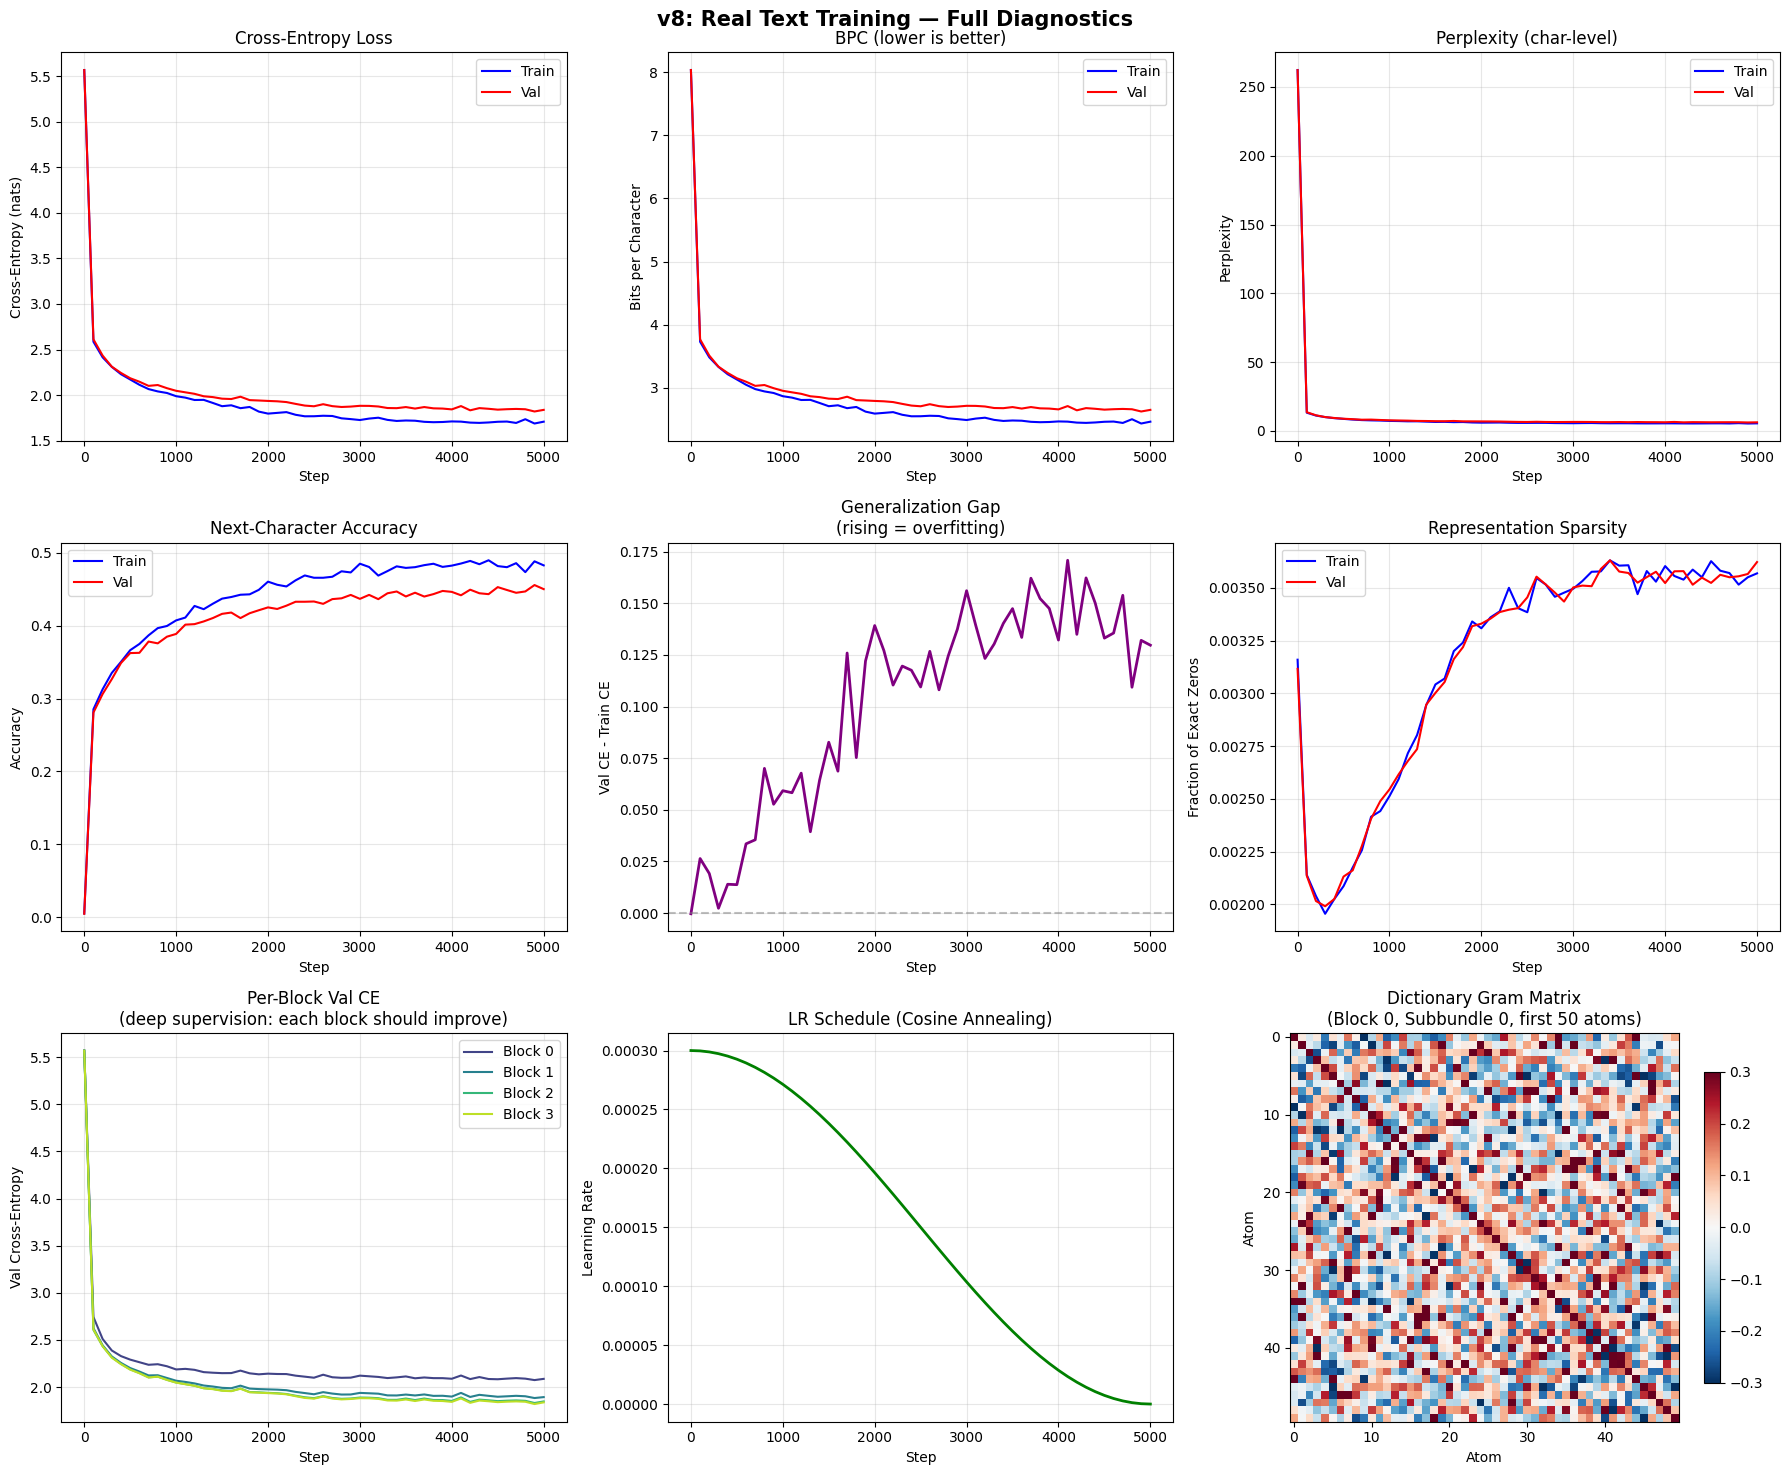


SUMMARY
Final Val CE:         1.837 nats
Final Val BPC:        2.65 bits/char
Final Val Perplexity: 6.3
Final Val Accuracy:   45.0%
Final Sparsity:       0.4%
Generalization Gap:   0.130 nats

Per-block Val CE:     5.569 -> 2.612 -> 2.433 -> 2.312 -> 2.243 -> 2.185 -> 2.146 -> 2.101 -> 2.110 -> 2.075 -> 2.047 -> 2.030 -> 2.013 -> 1.987 -> 1.977 -> 1.960 -> 1.956 -> 1.982 -> 1.944 -> 1.940 -> 1.935 -> 1.931 -> 1.923 -> 1.903 -> 1.884 -> 1.877 -> 1.899 -> 1.878 -> 1.869 -> 1.873 -> 1.882 -> 1.881 -> 1.874 -> 1.858 -> 1.856 -> 1.868 -> 1.852 -> 1.868 -> 1.854 -> 1.852 -> 1.843 -> 1.879 -> 1.832 -> 1.857 -> 1.849 -> 1.840 -> 1.845 -> 1.848 -> 1.844 -> 1.820 -> 1.837
Block improvement:    0.249 nats (block 0 -> block 3)

Reference: LSTM char-LM ~ 1.5-2.0 BPC, Transformer char-LM ~ 1.1-1.3 BPC


In [99]:
steps = history["step"]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# --- Row 1: Core metrics ---

# 1. Cross-entropy loss
axes[0, 0].plot(steps, history["train_ce"], 'b-', label='Train')
axes[0, 0].plot(steps, history["val_ce"], 'r-', label='Val')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('Cross-Entropy (nats)')
axes[0, 0].set_title('Cross-Entropy Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Bits per character
axes[0, 1].plot(steps, history["train_bpc"], 'b-', label='Train')
axes[0, 1].plot(steps, history["val_bpc"], 'r-', label='Val')
axes[0, 1].set_xlabel('Step')
axes[0, 1].set_ylabel('Bits per Character')
axes[0, 1].set_title('BPC (lower is better)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Character-level perplexity
val_ppl = [math.exp(ce) for ce in history["val_ce"]]
train_ppl = [math.exp(ce) for ce in history["train_ce"]]
axes[0, 2].plot(steps, train_ppl, 'b-', label='Train')
axes[0, 2].plot(steps, val_ppl, 'r-', label='Val')
axes[0, 2].set_xlabel('Step')
axes[0, 2].set_ylabel('Perplexity')
axes[0, 2].set_title('Perplexity (char-level)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# --- Row 2: Accuracy, overfitting, sparsity ---

# 4. Next-character accuracy
axes[1, 0].plot(steps, history["train_acc"], 'b-', label='Train')
axes[1, 0].plot(steps, history["val_acc"], 'r-', label='Val')
axes[1, 0].set_xlabel('Step')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Next-Character Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Generalization gap (overfitting indicator)
gap = [t - v for t, v in zip(history["val_ce"], history["train_ce"])]
axes[1, 1].plot(steps, gap, 'purple', linewidth=2)
axes[1, 1].set_xlabel('Step')
axes[1, 1].set_ylabel('Val CE - Train CE')
axes[1, 1].set_title('Generalization Gap\n(rising = overfitting)')
axes[1, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].grid(True, alpha=0.3)

# 6. Sparsity
axes[1, 2].plot(steps, history["train_sparsity"], 'b-', label='Train')
axes[1, 2].plot(steps, history["val_sparsity"], 'r-', label='Val')
axes[1, 2].set_xlabel('Step')
axes[1, 2].set_ylabel('Fraction of Exact Zeros')
axes[1, 2].set_title('Representation Sparsity')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

# --- Row 3: Deep supervision, LR schedule, dictionary ---

# 7. Per-block validation CE (deep supervision diagnostic)
block_labels = [f'Block {i}' for i in range(config.n_blocks)]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, config.n_blocks))
for b_idx in range(config.n_blocks):
    axes[2, 0].plot(steps, history["block_val_ces"][b_idx],
                    color=colors[b_idx], label=block_labels[b_idx])
axes[2, 0].set_xlabel('Step')
axes[2, 0].set_ylabel('Val Cross-Entropy')
axes[2, 0].set_title('Per-Block Val CE\n(deep supervision: each block should improve)')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 8. Learning rate schedule
axes[2, 1].plot(steps, history["lr"], 'green', linewidth=2)
axes[2, 1].set_xlabel('Step')
axes[2, 1].set_ylabel('Learning Rate')
axes[2, 1].set_title('LR Schedule (Cosine Annealing)')
axes[2, 1].grid(True, alpha=0.3)

# 9. Dictionary atom gram matrix (block 0)
with torch.no_grad():
    D = F.normalize(model.blocks[0].memory_bank.dictionaries[0], dim=-1)
    gram = (D @ D.T).cpu().numpy()

im = axes[2, 2].imshow(gram[:50, :50], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[2, 2].set_title('Dictionary Gram Matrix\n(Block 0, Subbundle 0, first 50 atoms)')
axes[2, 2].set_xlabel('Atom')
axes[2, 2].set_ylabel('Atom')
plt.colorbar(im, ax=axes[2, 2], shrink=0.8)

plt.suptitle('v8: Real Text Training — Full Diagnostics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n{'='*60}")
print(f"SUMMARY")
print(f"{'='*60}")
print(f"Final Val CE:         {history['val_ce'][-1]:.3f} nats")
print(f"Final Val BPC:        {history['val_bpc'][-1]:.2f} bits/char")
print(f"Final Val Perplexity: {val_ppl[-1]:.1f}")
print(f"Final Val Accuracy:   {history['val_acc'][-1]:.1%}")
print(f"Final Sparsity:       {history['val_sparsity'][-1]:.1%}")
print(f"Generalization Gap:   {gap[-1]:.3f} nats")
print(f"\nPer-block Val CE:     {' -> '.join(f'{c:.3f}' for c in history['block_val_ces'][-1] if isinstance(c, float))}")
print(f"Block improvement:    {history['block_val_ces'][0][-1] - history['block_val_ces'][-1][-1]:.3f} nats (block 0 -> block {config.n_blocks-1})")
print(f"\nReference: LSTM char-LM ~ 1.5-2.0 BPC, Transformer char-LM ~ 1.1-1.3 BPC")

---
## 7. Text Generation

In [100]:
@torch.no_grad()
def generate_text(model, prompt_str, max_new_chars=200, temperature=0.8):
    """Generate text autoregressively from a string prompt."""
    model.eval()
    cfg = model.cfg
    device = next(model.parameters()).device

    token_ids = torch.tensor(encode(prompt_str), dtype=torch.long).unsqueeze(0).to(device)

    for _ in range(max_new_chars):
        T = token_ids.size(1)
        if T >= cfg.max_seq_len:
            # Sliding window: keep last max_seq_len tokens
            context = token_ids[:, -cfg.max_seq_len:]
        else:
            context = token_ids

        logits, _ = model(context)
        next_logits = logits[:, -1, :] / temperature

        probs = F.softmax(next_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)

        token_ids = torch.cat([token_ids, next_token], dim=1)

    return decode(token_ids[0].tolist())


print("=" * 60)
print("TEXT GENERATION (temperature=0.8)")
print("=" * 60)

prompts = [
    "ROMEO:\n",
    "To be or not to ",
    "The king ",
    "O, ",
]

for prompt in prompts:
    print(f"\n--- Prompt: {repr(prompt)} ---")
    generated = generate_text(model, prompt, max_new_chars=200)
    print(generated)
    print()

TEXT GENERATION (temperature=0.8)

--- Prompt: 'ROMEO:\n' ---
ROMEO:

HREOM:B
u
n
eTxmeems'  fsotmheorl,  tahkmlayi ntou rgaatroyt ydoaocneesdtieonn,e
mFe rguee  wahs  ssciluisto -ihn  bnuatlwy  wterneedn
eAvNeVs:t otn emvpeerpsa cthreeed  afntor  tshuisneedn?e
rBoErT,


--- Prompt: 'To be or not to ' ---
To be or not to  gtorneor .g
rAeUdM yyeatnoe swaoiunsdteedd  ysoel ah tthaen  tthios,e dyielsd,a
rIeAnLdo  tahk'esrtoartt
eTyienr yooutn eaarm  iisthe rGoHrse;  aSnmeinngesr,e daiyn sgooodd. 
IT atn ips eonneasreisg 


--- Prompt: 'The king ' ---
The king  tthues  Gtoirse liofu rhoilcihceh .l
ehoargse  tyorunset yooudreesf;o
,HoU,T :V
Ic atntelrl,o
u
saeym esyt yfoarlsy  awna tthoeu sloatdess  tahkneivne  lliokn ionu,e rweael sseievse ntor ktirmeansd a


--- Prompt: 'O, ' ---
O,  mIe rsevlel ftoirs  mIy  tghitliya lbeatse dootdhe naordd edlwanrtye tahr egaiinsg ewviecsh yaonl yDoutgh,t
 Thhiacmearn' dtihmte,r etvuer  hwearr obflrievveen :I
 tlhutchh ywoa tthrianl ygeasdtiennd



---
## 8. Geometric Analysis on Real Text

Examine the architecture's internal representations on natural language:
- Sparsity evolution during Langevin settling
- Cross-position influence (does the causal mixing learn meaningful patterns?)
- Per-step context weights (what schedule did the model learn?)

Analyzing: 'Second Citizen:
Would you proceed especially against Caius M...'


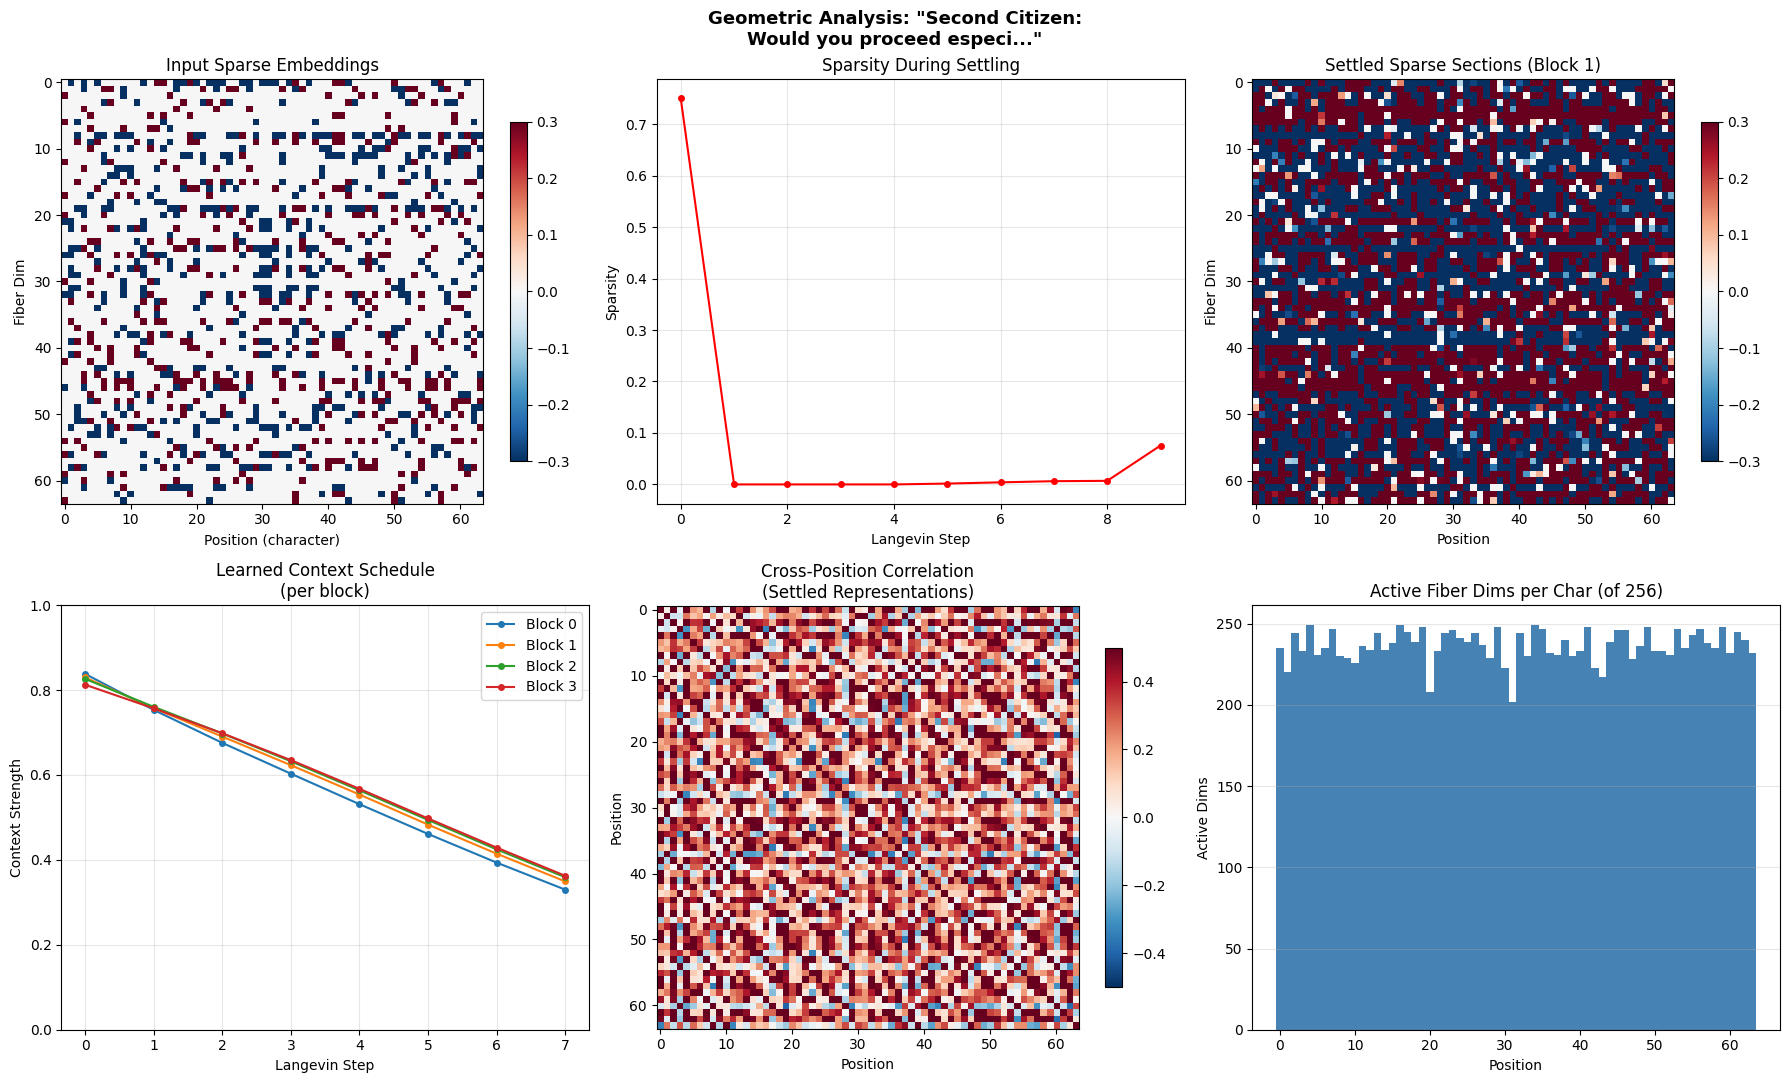

In [101]:
@torch.no_grad()
def analyze_real_text(model, text_snippet, cfg):
    model.eval()
    device = next(model.parameters()).device

    tokens = torch.tensor(encode(text_snippet[:cfg.seq_len]), dtype=torch.long)
    tokens = tokens.unsqueeze(0).to(device)

    x_sparse, q_coords = model.embedding(tokens)
    block = model.blocks[0]
    x_out, trajectory = block(x_sparse, q_coords, return_trajectory=True)

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))

    # 1. Input text as token heatmap
    text_chars = list(text_snippet[:cfg.seq_len])
    x_in = x_sparse[0].cpu().numpy()
    im1 = axes[0, 0].imshow(x_in.T[:64], aspect='auto', cmap='RdBu_r', vmin=-0.3, vmax=0.3)
    axes[0, 0].set_xlabel('Position (character)')
    axes[0, 0].set_ylabel('Fiber Dim')
    axes[0, 0].set_title('Input Sparse Embeddings')
    plt.colorbar(im1, ax=axes[0, 0], shrink=0.8)

    # 2. Sparsity evolution
    sparsities = [(t == 0).float().mean().item() for t in trajectory]
    axes[0, 1].plot(sparsities, 'r-o', markersize=4)
    axes[0, 1].set_xlabel('Langevin Step')
    axes[0, 1].set_ylabel('Sparsity')
    axes[0, 1].set_title('Sparsity During Settling')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Settled output
    x_final = trajectory[-1][0].cpu().numpy()
    im3 = axes[0, 2].imshow(x_final.T[:64], aspect='auto', cmap='RdBu_r', vmin=-0.3, vmax=0.3)
    axes[0, 2].set_xlabel('Position')
    axes[0, 2].set_ylabel('Fiber Dim')
    axes[0, 2].set_title('Settled Sparse Sections (Block 1)')
    plt.colorbar(im3, ax=axes[0, 2], shrink=0.8)

    # 4. Per-step context weights (all blocks)
    for b_idx, blk in enumerate(model.blocks):
        alphas = torch.sigmoid(blk.seq_langevin.score_fn.step_context_logits).cpu().numpy()
        axes[1, 0].plot(alphas, '-o', markersize=4, label=f'Block {b_idx}')
    axes[1, 0].set_xlabel('Langevin Step')
    axes[1, 0].set_ylabel('Context Strength')
    axes[1, 0].set_title('Learned Context Schedule\n(per block)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim(0, 1)

    # 5. Cross-position correlation in final settled state
    x_f = trajectory[-1][0]  # (T, D)
    x_normed = F.normalize(x_f, dim=-1)
    corr = (x_normed @ x_normed.T).cpu().numpy()
    im5 = axes[1, 1].imshow(corr, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    axes[1, 1].set_xlabel('Position')
    axes[1, 1].set_ylabel('Position')
    axes[1, 1].set_title('Cross-Position Correlation\n(Settled Representations)')
    plt.colorbar(im5, ax=axes[1, 1], shrink=0.8)

    # 6. Active dimensions per position
    active = (x_f.abs() > 1e-6).float().sum(-1).cpu().numpy()
    axes[1, 2].bar(range(len(active)), active, color='steelblue', width=1.0)
    axes[1, 2].set_xlabel('Position')
    axes[1, 2].set_ylabel('Active Dims')
    axes[1, 2].set_title(f'Active Fiber Dims per Char (of {cfg.fiber_dim})')
    axes[1, 2].grid(True, alpha=0.3, axis='y')

    plt.suptitle(f'Geometric Analysis: "{text_snippet[:40]}..."',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Analyze a Shakespeare passage
sample_text = text[1000:1000 + config.seq_len]
print(f"Analyzing: '{sample_text[:60]}...'")
analyze_real_text(model, sample_text, config)

---
## 9. Summary

### v8: First Real Text Training

**Data**: Tiny Shakespeare (~1M characters), character-level tokenization (vocab=256).  
**Architecture**: v7.3 (sequence-level diffusion routing with deep supervision).  
**Training**: Step-based, 5000 steps, batch_size=16, seq_len=64.

This is the architecture's first contact with natural language.  
The synthetic task validated the mechanisms; now we test whether  
the geometric framework can learn the statistical structure of English.

### What to Watch For

1. **Does the model learn character-level patterns?** (spaces after words,  
   common bigrams like 'th', 'he', 'in', 'er')
2. **Does it learn word boundaries?** (space prediction accuracy)
3. **Do the cross-position correlations reflect linguistic structure?**  
   (characters within a word should correlate more than across words)
4. **Does the context schedule differ from synthetic?**  
   (natural language may need different explore/exploit balance)

---
*v8 notebook by David Ledbetter, 03/13/2026.*  
*First real text experiment: Tiny Shakespeare, character-level.*